In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [5]:
IMAGE_SIZE = (224, 224)

In [6]:
def load_image(image_path):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMAGE_SIZE
    )

    image = tf.keras.utils.img_to_array(image)

    # Convert 0-255 to 0-1
    image = image / 255.0

    # Add batch dimension
    image = tf.expand_dims(image, axis=0)

    return image

In [7]:
brightness_layer = tf.keras.layers.RandomBrightness(
    factor=0.15,
    value_range=(0, 1)
)

In [8]:
contrast_layer = tf.keras.layers.RandomContrast(
    factor=0.15
)

In [9]:
rotation_layer = tf.keras.layers.RandomRotation(
    factor=0.05
)

In [10]:
def create_variations(image):

    brightness_image = brightness_layer(
        image,
        training=True
    )

    contrast_image = contrast_layer(
        image,
        training=True
    )

    rotation_image = rotation_layer(
        image,
        training=True
    )

    return {
        "Original": image,
        "Brightness": brightness_image,
        "Contrast": contrast_image,
        "Rotation": rotation_image
    }

In [14]:
from pathlib import Path

SAMPLE_DIR = Path("/content/smaple_images")

sample_paths = sorted([
    p for p in SAMPLE_DIR.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

print("Number of images:", len(sample_paths))

Number of images: 5


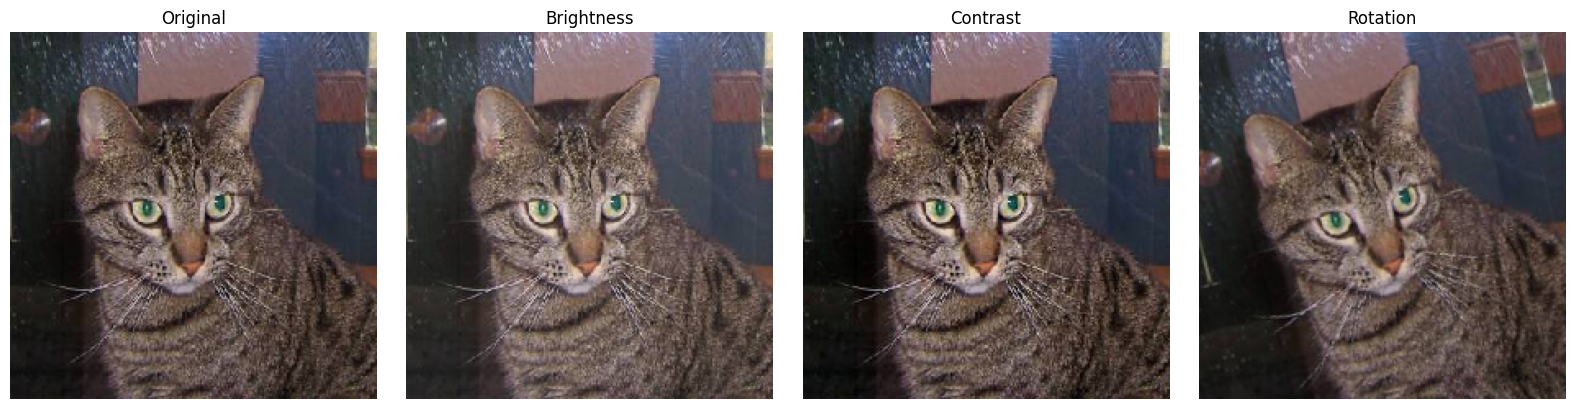

In [15]:
sample_image = load_image(sample_paths[0])

variations = create_variations(sample_image)

plt.figure(figsize=(16, 4))

for i, (name, image) in enumerate(variations.items()):

    plt.subplot(1, 4, i + 1)

    plt.imshow(
        tf.clip_by_value(
            image[0],
            0,
            1
        )
    )

    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
def get_prediction(model, image, threshold=0.5):

    probability = float(
        model.predict(
            image,
            verbose=0
        )[0][0]
    )

    prediction = int(
        probability >= threshold
    )

    return prediction, probability

In [19]:
from tensorflow.keras.models import load_model

baseline_cnn = load_model('/content/cnn_baseline.keras')
regularized_cnn = load_model('/content/cnn_regularized.keras')
deep_cnn = load_model('/content/cnn_deep.keras')

In [21]:
image = load_image(sample_paths[0])

models = {
    "Baseline CNN": baseline_cnn,
    "Regularized CNN": regularized_cnn,
    "Deep CNN": deep_cnn
}

for model_name, model in models.items():

    prediction, probability = get_prediction(
        model,
        image
    )

    class_name = "Dog" if prediction == 1 else "Cat"

    print(
        f"{model_name}: "
        f"{class_name} "
        f"({probability:.2%})"
    )

Baseline CNN: Cat (12.27%)
Regularized CNN: Cat (31.01%)
Deep CNN: Cat (3.75%)


In [23]:
ensemble_robustness_results = []

for image_path in sample_paths:

    original_image = load_image(image_path)

    variations = create_variations(
        original_image
    )

    for transformation, image in variations.items():

        baseline_probability = get_prediction(
            baseline_cnn,
            image
        )[1]

        regularized_probability = get_prediction(
            regularized_cnn,
            image
        )[1]

        deep_probability = get_prediction(
            deep_cnn,
            image
        )[1]

        ensemble_probability = (
            baseline_probability
            + regularized_probability
            + deep_probability
        ) / 3

        ensemble_prediction = int(
            ensemble_probability >= 0.5
        )

        ensemble_class = (
            "Dog"
            if ensemble_prediction == 1
            else "Cat"
        )

        ensemble_robustness_results.append({
            "image": image_path.name,
            "transformation": transformation,
            "model": "Ensemble CNN",
            "prediction": ensemble_class,
            "probability": ensemble_probability
        })

In [26]:
robustness_results = []

models = {
    "Baseline CNN": baseline_cnn,
    "Regularized CNN": regularized_cnn,
    "Deep CNN": deep_cnn
}

for image_path in sample_paths:

    original_image = load_image(image_path)

    variations = create_variations(
        original_image
    )

    for transformation, image in variations.items():

        for model_name, model in models.items():

            prediction, probability = get_prediction(
                model,
                image
            )

            predicted_class = (
                "Dog"
                if prediction == 1
                else "Cat"
            )

            robustness_results.append({
                "image": image_path.name,
                "transformation": transformation,
                "model": model_name,
                "prediction": predicted_class,
                "probability": probability
            })

In [28]:
ensemble_df = pd.DataFrame(
    ensemble_robustness_results
)
robustness_df=pd.DataFrame(
    robustness_results
)

In [29]:
complete_robustness_df = pd.concat(
    [
        robustness_df,
        ensemble_df
    ],
    ignore_index=True
)

complete_robustness_df

,image,transformation,model,prediction,probability
0,1.jpg,Original,Baseline CNN,Cat,0.122672
1,1.jpg,Original,Regularized CNN,Cat,0.310093
2,1.jpg,Original,Deep CNN,Cat,0.037472
3,1.jpg,Brightness,Baseline CNN,Cat,0.122641
4,1.jpg,Brightness,Regularized CNN,Cat,0.310139
5,1.jpg,Brightness,Deep CNN,Cat,0.037469
6,1.jpg,Contrast,Baseline CNN,Cat,0.122656
7,1.jpg,Contrast,Regularized CNN,Cat,0.310078
8,1.jpg,Contrast,Deep CNN,Cat,0.037472
9,1.jpg,Rotation,Baseline CNN,Cat,0.122785


In [30]:
complete_robustness_df.to_csv(
     "robustness_results.csv",
    index=False
)